In [8]:
import numpy as np
from scipy.optimize import minimize
import maxcut_qaoa as qaoa
from qiskit.visualization import plot_histogram
import networkx as nx
from pyvis import network as pvnet
from matplotlib import pyplot as plt
plt.style.use('seaborn')

# Max-Cut

#### Application: Clustering within Autonomous Sensor Data

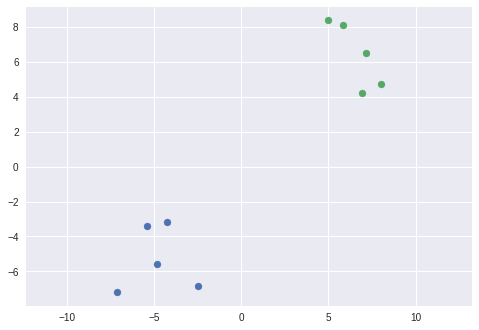

In [9]:
# set up two random distributions with n_points total points
n_points = 10
n1 = n_points//2
n2 = n_points//2
set1  = np.random.normal(-5, 2, (2, n1))
set2 = np.random.normal(5, 2, (2, n2))
plt.scatter(set1[0, :], set1[1, :])
plt.scatter(set2[0, :], set2[1, :])
plt.axis('equal')
plt.show()     

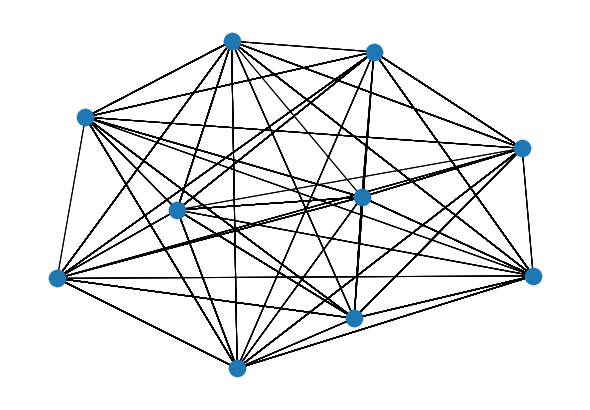

In [10]:
# create a dictionary mapping points to nodes
combined_set = np.hstack((set1, set2))
nodes_points = dict()
counter = 0
for column in range(combined_set.shape[1]):
    nodes_points[counter] = combined_set[:, column]
    counter += 1
nodes = nodes_points.keys()

# now set up edges between the nodes corresponding to distances between nodes
edges = []
for node1 in nodes:
    point1 = nodes_points[node1]
    for node2 in nodes:
        point2 = nodes_points[node2]
        if node1 != node2:
            for i in range(round(np.linalg.norm(point1 - point2))):
                edges.append((node1, node2))

# now draw the graph with the nodes and edges we've set up
G = nx.MultiGraph(edges)
nx.draw(G)

In [11]:
# # visualize our graph
# def plot_g_pyviz(G, name='maxcut_graph.html', height='500px', width='800px'):
#     g = G.copy() # some attributes added to nodes
#     net = pvnet.Network(notebook=True, directed=True, height=height,
#                         width=width)
#     #a note for the above line: the graph has to be directed, even
#     #if it really isn't, if we are to show multiple edges when we
#     #plot it using pyvis
#     net.from_nx(g)
# #     net.toggle_physics(False) #comment out for multiple edges between node pairs
#     net.set_edge_smooth('dynamic')
#     return net.show(name)
# plot_g_pyviz(G)

     fun: -546.845703125
   maxcv: 0.0
 message: 'Optimization terminated successfully.'
    nfev: 69
  status: 1
 success: True
       x: array([4.5267293 , 4.15835902, 2.77053317, 5.56706468, 3.89713159,
       0.23482694])


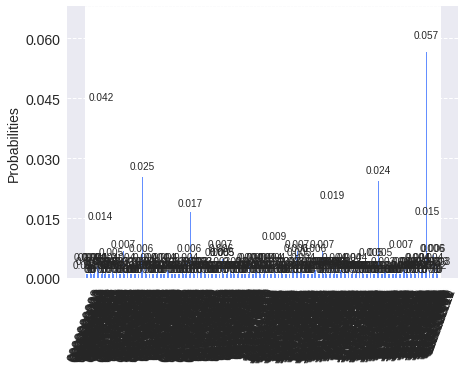

In [12]:
# get the expectation function from qaoa.py
p = 3 #number of layers
expectation = qaoa.get_expectation(G, p)

# minimize the expectation, trying a few times with random ICs
check, sol = 0, 0
for k in range(5):
    res = minimize(expectation, 
                      np.random.uniform(0, 5, 2*p), #initial params beta and gamma
                      method='COBYLA')
    if res.fun < check:
        check = res.fun
        sol = res
print(sol)
counts = expectation(sol.x, return_counts=True)[1]
plot_histogram(counts)

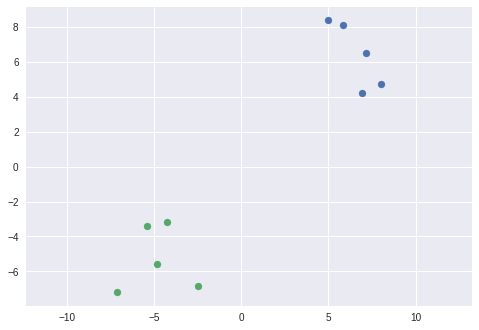

In [13]:
# convert the result back to points and plot our clusters
opt_bitstring = list(counts.keys())[np.argmax(list(counts.values()))]
# print(qaoa.maxcut_obj('000000111111', G) - 
#       qaoa.maxcut_obj(opt_bitstring, G))
cluster0, cluster1 = [], []
counter = 0
for char in opt_bitstring:
    if int(char) == 0:
        cluster0.append(nodes_points[counter])
    else:
        cluster1.append(nodes_points[counter])
    counter += 1
    
cluster0 = np.vstack((cluster0)).T
cluster1 = np.vstack((cluster1)).T

plt.scatter(cluster0[0, :], cluster0[1, :])
plt.scatter(cluster1[0, :], cluster1[1, :])
plt.axis('equal')
plt.show()

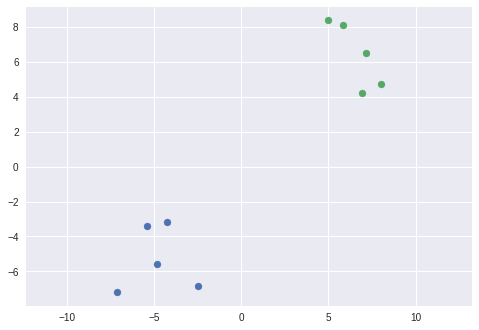

In [14]:
# replot the original points for comparison
plt.scatter(set1[0, :], set1[1, :])
plt.scatter(set2[0, :], set2[1, :])
plt.axis('equal')
plt.show()